In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import gymnasium as gym
from stable_baselines3 import PPO, DQN, TD3
from stable_baselines3.common.evaluation import evaluate_policy
from gymnasium import spaces

from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder

# Train the actor-critic models (TD3)

In [3]:
# Custom wrapper for continuous rewards
class ContinuousRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Convert to continuous reward based on state
        continuous_reward = self._compute_continuous_reward(obs, terminated, truncated)
        
        # Add observation noise if enabled
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
        
        return obs, continuous_reward, terminated, truncated, info
    
    def _compute_continuous_reward(self, obs, terminated, truncated):
        """
        Compute continuous reward based on the state
        """
        if len(obs) >= 4:
            x, theta, x_dot, theta_dot = obs[:4]
        else:
            x, theta, x_dot, theta_dot = obs[0], obs[1], 0, 0
        
        # Base reward for staying alive
        reward = 1.0
        
        # Angle reward (most important - stay upright)
        angle_reward = np.exp(-5 * theta**2)
        reward += 2.0 * angle_reward
        
        # Position reward (stay centered)
        position_reward = np.exp(-0.5 * x**2)
        reward += 0.5 * position_reward
        
        # Stability reward (minimize velocities)
        velocity_penalty = 0.1 * (x_dot**2 + theta_dot**2)
        reward -= velocity_penalty
        
        # Large penalty for falling
        if terminated:
            reward -= 10.0
        
        # Bonus for being very stable
        if abs(theta) < 0.1 and abs(theta_dot) < 0.1:
            reward += 0.5
        
        return reward
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)
            obs = obs + noise
            
        return obs, info

def train_multiple_td3_models():
    """
    Train multiple TD3 models with different training timesteps on continuous rewards
    """
    
    # Define training configurations
    training_configs = [
        # {
        #     "timesteps": 50000,
        #     "name": "50k"
        # },
        # {
        #     "timesteps": 100000, 
        #     "name": "100k"
        # },
        # {
        #     "timesteps": 300000,
        #     "name": "300k"
        # },
        # {
        #     "timesteps": 500000, 
        #     "name": "500k"
        # },
        # {
        #     "timesteps": 1000000, 
        #     "name": "1000k"
        # },
        {
            "timesteps": 2000000, 
            "name": "2000k"
        },
        {
            "timesteps": 3000000, 
            "name": "3000k"
        },

    ]
    
    trained_models = {}
    
    print("=== Training Multiple TD3 Models with Continuous Rewards ===\n")
    
    for i, config in enumerate(training_configs):
        timesteps = config["timesteps"]
        name = config["name"]
        
        print(f"Training Model {i+1}/{len(training_configs)}: {name} steps ({timesteps} timesteps)")
        print("-" * 50)
        
        # Create fresh environment for each model with continuous rewards
        env = ContinuousRewardCartPole(gym.make("InvertedPendulum-v5"))
        
        # Create TD3 model with your exact specifications
        model = TD3("MlpPolicy", env, verbose=1,
                    learning_rate=0.001,
                    buffer_size=100000,
                    learning_starts=10000,
                    batch_size=256,
                    gamma=0.99)
        
        print(f"Starting training for {timesteps} timesteps with continuous rewards...")
        
        # Train the model
        model.learn(total_timesteps=timesteps)
        
        # Save the model
        filename = f"td3_invertedpendulum_continuous_{name}_steps"
        model.save(filename)
        
        # Store in dictionary
        trained_models[name] = model
        
        print(f"✓ Model saved as: {filename}")
        print(f"✓ Training completed for {name} model\n")
        
        # Close environment to free memory
        env.close()
    
    print("=== All Models Trained Successfully! ===")
    print("Saved models:")
    for config in training_configs:
        print(f"  - td3_invertedpendulum_continuous_{config['name']}_steps.zip")
    
    return trained_models

def test_all_models(trained_models, num_episodes=3):
    """
    Test performance of all trained models with continuous rewards
    """
    
    print("\n=== Testing All Models with Continuous Rewards ===\n")
    
    results = {}
    
    for model_name, model in trained_models.items():
        print(f"Testing {model_name} model...")
        
        env = ContinuousRewardCartPole(gym.make("InvertedPendulum-v5"))
        
        episode_rewards = []
        episode_lengths = []
        
        for episode in range(num_episodes):
            obs, _ = env.reset()
            episode_reward = 0
            steps = 0
            
            for step in range(1000):  # Max 1000 steps per episode
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = env.step(action)
                episode_reward += reward
                steps += 1
                
                if terminated or truncated:
                    break
            
            episode_rewards.append(episode_reward)
            episode_lengths.append(steps)
        
        avg_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)
        avg_length = np.mean(episode_lengths)
        std_length = np.std(episode_lengths)
        
        results[model_name] = {
            'avg_reward': avg_reward,
            'std_reward': std_reward,
            'avg_length': avg_length,
            'std_length': std_length
        }
        
        print(f"  Average Reward: {avg_reward:.2f} ± {std_reward:.2f}")
        print(f"  Average Length: {avg_length:.2f} ± {std_length:.2f}")
        print()
        
        env.close()
    
    # Print comparison
    print("=== Model Comparison (Continuous Rewards) ===")
    for model_name, stats in results.items():
        print(f"{model_name:>10}: Reward = {stats['avg_reward']:6.2f} ± {stats['std_reward']:5.2f}, "
              f"Length = {stats['avg_length']:6.2f} ± {stats['std_length']:5.2f}")
    
    return results

# Main execution - train automatically with continuous rewards
if __name__ == "__main__":
    # Train all models
    trained_models = train_multiple_td3_models()
    
    # Test all models
    test_results = test_all_models(trained_models)

=== Training Multiple TD3 Models with Continuous Rewards ===

Training Model 1/2: 2000k steps (2000000 timesteps)
--------------------------------------------------
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training for 2000000 timesteps with continuous rewards...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 9.25     |
|    ep_rew_mean     | 18.7     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 6150     |
|    time_elapsed    | 0        |
|    total_timesteps | 37       |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 8.62     |
|    ep_rew_mean     | 16.5     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 4253     |
|    time_elapsed    | 0        |
|    total_timesteps | 69       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.5      |
|    ep_rew_mean     | 12.3     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 4426     |
|    time_elapsed    | 0        |
|    total_timesteps | 90       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.69     |
|    ep_rew_mean     | 12.8     |
| time/              |          |
|    episodes        | 16       |
|    fps             | 4547     |
|    time_elapsed    | 0        |
|    total_timesteps | 123      |
--------------

KeyboardInterrupt: 

# Get the Q value

In [2]:
import torch
from stable_baselines3 import TD3
import numpy as np

def get_q_value(model_path, state, action):
    """
    Load a TD3 model and get Q-value for a specific state-action pair
    
    Args:
        model_path (str): Path to the saved TD3 model (.zip file)
        state (array-like): State vector [x, theta, x_dot, theta_dot]
        action (float or array-like): Action value (scalar for 1D action space)
    
    Returns:
        tuple: (q1_value, q2_value, min_q_value) - Both Q-values and their minimum
    """
    # Load the model
    model = TD3.load(model_path)
    
    # Convert inputs to proper format
    if isinstance(state, (list, tuple)):
        state = np.array(state, dtype=np.float32)
    if isinstance(action, (int, float)):
        action = np.array([action], dtype=np.float32)
    elif isinstance(action, (list, tuple)):
        action = np.array(action, dtype=np.float32)
    
    # Reshape for batch processing
    state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(model.device)
    action_tensor = torch.FloatTensor(action.reshape(1, -1)).to(model.device)
    
    # Get Q-values from both critics
    with torch.no_grad():
        # Concatenate state and action as input to Q-networks
        state_action = torch.cat([state_tensor, action_tensor], dim=1)
        q1_value = model.critic.qf0(state_action).item()
        q2_value = model.critic.qf1(state_action).item()
        min_q_value = min(q1_value, q2_value)  # TD3 uses minimum of both Q-values
    
    return q1_value, q2_value, min_q_value

# Example usage:

test_state = [0.0, 0.1, 0.0, 0.0]  # Slightly tilted pendulum
test_action = 0.5  # Some action value
    
# Get Q-values for 50k model
q1, q2, min_q = get_q_value("td3_invertedpendulum_continuous_50k_steps.zip", test_state, test_action)
print(f"State: {test_state}")
print(f"Action: {test_action}")
print(f"Q1-value: {q1:.3f}")
print(f"Q2-value: {q2:.3f}")
print(f"Min Q-value: {min_q:.3f}")
        
 

State: [0.0, 0.1, 0.0, 0.0]
Action: 0.5
Q1-value: 216.120
Q2-value: 216.349
Min Q-value: 216.120


# Q value heatmap

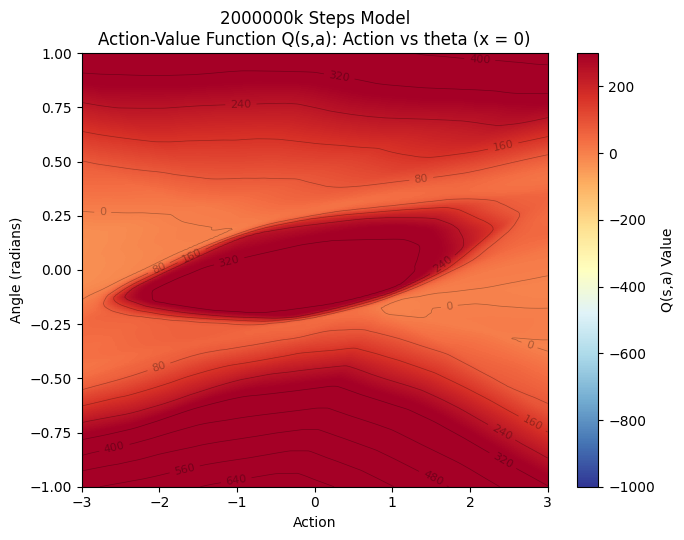

In [6]:
def create_q_heatmap(state_range2, action_range, model_path, grid_size=50, 
                     state_dims=['x', 'theta'], fixed_x=0):
    """
    Create heatmap of Q(s,a) values
    
    Args:
        state_range2: tuple (min, max) for second state dimension (y-axis)
        action_range: tuple (min, max) for action values (x-axis)
        model_path: path to saved TD3 model
        grid_size: number of grid points per dimension
        state_dims: which state dimensions to vary
        fixed_x: fixed value for x position
    """
    import torch
    import re
    
    # Extract model info from path
    model_info = "Unknown Model"
    if "50k" in model_path.lower():
        model_info = "50k Steps Model"
    elif "300k" in model_path.lower():
        model_info = "300k Steps Model"
    else:
        # Try to extract number followed by 'k'
        match = re.search(r'(\d+)k', model_path.lower())
        if match:
            steps = match.group(1)
            model_info = f"{steps}k Steps Model"
    
    # Load model
    model = TD3.load(model_path)
    
    # Create grid - ACTION on x-axis, STATE on y-axis
    action_vals = np.linspace(action_range[0], action_range[1], grid_size)
    state_vals = np.linspace(state_range2[0], state_range2[1], grid_size)
    
    # Initialize Q-value matrix
    q_values = np.zeros((grid_size, grid_size))
    
    # Default state values
    default_state = [0.0, 0.0, 0.0, 0.0]  # [x, theta, x_dot, theta_dot]
    
    # Map state dimensions
    dim_map = {'x': 0, 'theta': 1, 'x_dot': 2, 'theta_dot': 3}
    dim1_idx = dim_map[state_dims[0]]  # x dimension
    dim2_idx = dim_map[state_dims[1]]  # theta dimension
    
    # Compute Q-values
    for i, action_val in enumerate(action_vals):  # x-axis: actions
        for j, state_val in enumerate(state_vals):  # y-axis: theta
            # Create state
            state = default_state.copy()
            state[dim1_idx] = fixed_x      # Fixed x value
            state[dim2_idx] = state_val    # Varying theta
            state_vec = np.array(state)
            
            # Create action
            action = np.array([action_val])
            
            # Get Q(s,a)
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state_vec).unsqueeze(0)
                action_tensor = torch.FloatTensor(action).unsqueeze(0)
                q_value = model.critic.q1_forward(state_tensor, action_tensor).item()
            
            q_values[j, i] = q_value
    
    # Create heatmap with improved styling
    plt.figure(figsize=(7, 5.5))
    plt.imshow(q_values, extent=[action_range[0], action_range[1], 
                                state_range2[0], state_range2[1]], 
               aspect='auto', origin='lower', cmap='RdYlBu_r', vmin=-1000, vmax=300)
    plt.colorbar(label='Q(s,a) Value')
    plt.xlabel('Action')
    plt.ylabel('Angle (radians)')
    plt.title(f'{model_info}\nAction-Value Function Q(s,a): Action vs {state_dims[1]} ({state_dims[0]} = {fixed_x})')

    plt.tight_layout()
    
    # Add contour lines for better visualization
    X, Y = np.meshgrid(action_vals, state_vals)
    contours = plt.contour(X, Y, q_values, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    plt.clabel(contours, inline=True, fontsize=8)
    
    plt.show()
    
    return q_values

# Usage
q_heatmap = create_q_heatmap(
    state_range2=(-1, 1),      # angle range (y-axis)
    action_range=(-3, 3),      # action range (x-axis)
    model_path="td3_invertedpendulum_continuous_2000000k_steps.zip",
    grid_size=200,
    state_dims=['x', 'theta'],
    fixed_x=0
)

## V(s) heatmap

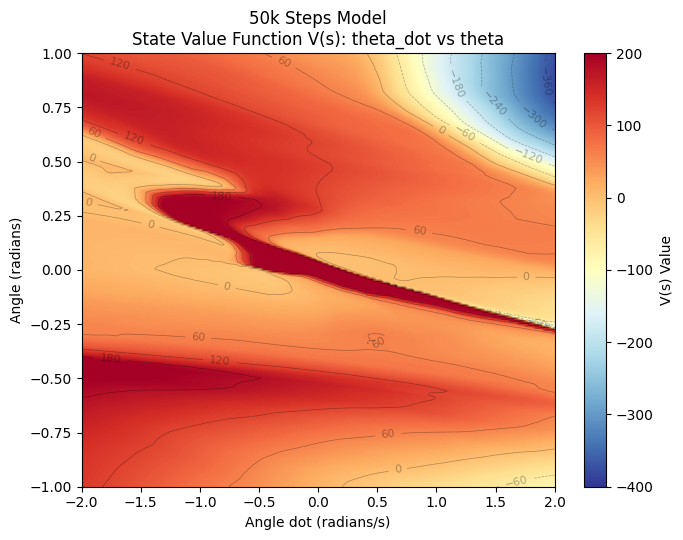

In [55]:
def create_v_heatmap_2d(state_range1, state_range2, model_path, grid_size=50, 
                        state_dims=['x', 'theta']):
    """
    Create 2D heatmap of V(s) ≈ Q(s, π(s)) using the learned policy
    
    Args:
        state_range1: tuple (min, max) for first state dimension (x-axis)
        state_range2: tuple (min, max) for second state dimension (y-axis)  
        model_path: path to saved TD3 model
        grid_size: number of grid points per dimension
        state_dims: which state dimensions to vary
    """
    import torch
    import re
    
    # Extract model info from path
    model_info = "Unknown Model"
    if "50k" in model_path.lower():
        model_info = "50k Steps Model"
    elif "300k" in model_path.lower():
        model_info = "300k Steps Model"
    else:
        # Try to extract number followed by 'k'
        match = re.search(r'(\d+)k', model_path.lower())
        if match:
            steps = match.group(1)
            model_info = f"{steps}k Steps Model"
    
    # Load model
    model = TD3.load(model_path)
    
    # Create grid
    dim1_vals = np.linspace(state_range1[0], state_range1[1], grid_size)
    dim2_vals = np.linspace(state_range2[0], state_range2[1], grid_size)
    
    # Initialize V-value matrix
    v_values = np.zeros((grid_size, grid_size))
    
    # Default state values
    default_state = [0.0, 0.0, 0.0, 0.0]  # [x, theta, x_dot, theta_dot]
    
    # Map state dimensions
    dim_map = {'x': 0, 'theta': 1, 'x_dot': 2, 'theta_dot': 3}
    dim1_idx = dim_map[state_dims[0]]
    dim2_idx = dim_map[state_dims[1]]
    
    # Compute V-values
    for i, val1 in enumerate(dim1_vals):
        for j, val2 in enumerate(dim2_vals):
            # Create state
            state = default_state.copy()
            state[dim1_idx] = val1
            state[dim2_idx] = val2
            state_vec = np.array(state)
            
            # Get action from policy
            action, _ = model.predict(state_vec, deterministic=True)
            
            # Get V(s) ≈ Q(s, π(s))
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state_vec).unsqueeze(0)
                action_tensor = torch.FloatTensor(action).unsqueeze(0)
                v_value = model.critic.q1_forward(state_tensor, action_tensor).item()
            
            v_values[j, i] = v_value
    
    # Create heatmap
    plt.figure(figsize=(7, 5.5))
    plt.imshow(v_values, extent=[state_range1[0], state_range1[1], 
                                state_range2[0], state_range2[1]], 
               aspect='auto', origin='lower', cmap='RdYlBu_r', vmin=-400, vmax=200)
    plt.colorbar(label='V(s) Value')
    plt.xlabel('Angle dot (radians/s)')
    plt.ylabel('Angle (radians)')
    plt.title(f'{model_info}\nState Value Function V(s): {state_dims[0]} vs {state_dims[1]}')
    
    # Add contour lines for better visualization
    X, Y = np.meshgrid(dim1_vals, dim2_vals)
    contours = plt.contour(X, Y, v_values, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    plt.clabel(contours, inline=True, fontsize=8)

    plt.tight_layout()
    
    plt.show()
    
    return v_values

# Updated usage with flipped axes
v_heatmap = create_v_heatmap_2d(
    state_range1=(-2, 2),         # angular velocity range (x-axis)
    state_range2=(-1, 1),     # angle range (y-axis)
    model_path="td3_invertedpendulum_continuous_50k_steps.zip",
    grid_size=200,
    state_dims=['theta_dot', 'theta']  # Flipped: theta_dot on x, theta on y
)